Quizz Partie 2

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split

In [86]:
url = "https://raw.githubusercontent.com/OpenClassrooms-Student-Center/8063076-Initiez-vous-au-Machine-Learning/master/data/palmer_penguins_openclassrooms.csv"
df = pd.read_csv(url)

In [4]:
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Chinstrap,Dream,40.9,16.6,187.0,3200.0,female,2008
1,Adelie,Dream,36.5,18.0,182.0,3150.0,female,2007
2,Chinstrap,Dream,46.5,17.9,192.0,3500.0,female,2007
3,Gentoo,Biscoe,54.3,15.7,231.0,5650.0,male,2008
4,Gentoo,Biscoe,46.3,15.8,215.0,5050.0,male,2007
...,...,...,...,...,...,...,...,...
328,Chinstrap,Dream,52.0,19.0,197.0,4150.0,male,2007
329,Adelie,Dream,37.3,17.8,191.0,3350.0,female,2008
330,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female,2009
331,Chinstrap,Dream,46.4,18.6,190.0,3450.0,female,2007


# Q1. 3 univariate linear regression models

Regression for bill_length_mm:
 Train R^2: 0.348, Test R^2: 0.252
Regression for bill_depth_mm:
 Train R^2: 0.217, Test R^2: 0.135
Regression for flipper_length_mm:
 Train R^2: 0.760, Test R^2: 0.738


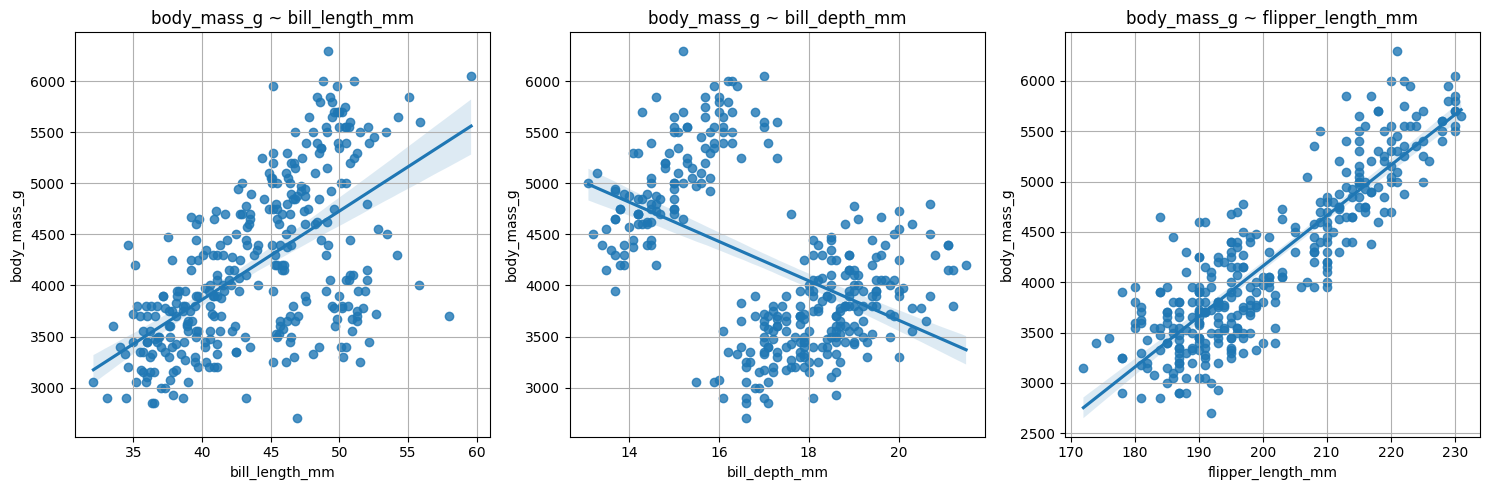

In [8]:
#let's separate to train and test sets
#predictors
Xs = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm']
#target
y = df['body_mass_g']

#Loop over each column in Xs
for col in Xs:
    X = df[col].values.reshape(-1, 1)

    #Split into train and test sets (80/20)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    #Train a linear regression model
    from sklearn.linear_model import LinearRegression
    reg = LinearRegression()
    reg.fit(X_train, y_train)

    #Evaluate the model
    y_pred = reg.predict(X_test)
    train_score = reg.score(X_train, y_train)
    test_score = reg.score(X_test, y_test)

    print(f"Regression for {col}:")
    print(f" Train R^2: {train_score:.3f}, Test R^2: {test_score:.3f}")

#3 scatter plots with the regression line
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, x in zip(axes, Xs):
    sns.regplot(data=df, x=x, y=y, ax=ax)
    ax.set_title(f"body_mass_g ~ {x}")
    ax.grid(True)

plt.tight_layout()
plt.show()

flipper_length has the biggest R^2 so it's the strongest predictor of these 3.

# 2. Multivariate linear regression model

In [21]:
from sklearn.preprocessing import MinMaxScaler
#split into train and test
X_train, X_test, y_train, y_test = train_test_split(df[Xs], y, test_size=0.2, random_state=42)

#init the scalre
scaler = MinMaxScaler()

#fit the scaler on the training data only
#transform both the training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#train the model on the scaled train data
reg.fit(X_train_scaled, y_train)

#predict
y_pred_scaled_test = reg.predict(X_test_scaled)
y_pred_scaled_train = reg.predict(X_train_scaled)

#evaluate
train_score_scaled = reg.score(X_train_scaled, y_train)
test_score_scaled = reg.score(X_test_scaled, y_test)

print(f"Train MAPE: {mean_absolute_percentage_error(y_train, y_pred_scaled_train)*100:.3f}%, Test MAPE: {mean_absolute_percentage_error(y_test, y_pred_scaled_test)*100:.3f}%")
print(f"Train RMSE: {mean_squared_error(y_train, y_pred_scaled_train):.3f}, Test RMSE: {mean_squared_error(y_test, y_pred_scaled_test):.3f}")
print(f"Train R^2: {r2_score(y_train, y_pred_scaled_train):.3f}, Test R^2: {r2_score(y_test, y_pred_scaled_test):.3f}")

Train MAPE: 7.763%, Test MAPE: 7.642%
Train RMSE: 159961.633, Test RMSE: 125638.815
Train R^2: 0.763, Test R^2: 0.733


MAPE is less than 10% which is excellent. It's equal to a relative error.

R^2 is close to 1 so it's good.

# 3. 3 different species modeles

In [29]:
for specie in ['Adelie', 'Chinstrap', 'Gentoo']:
    sub = df[df.species == specie].copy()
    y = sub['body_mass_g']
    X = sub[Xs]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc = scaler.transform(X_test)

    reg.fit(X_train_sc, y_train)

    y_pred_sc_train = reg.predict(X_train_sc)
    y_pred_sc_test = reg.predict(X_test_sc)

    print(f"--\n {specie} Train R^2: {r2_score(y_train, y_pred_sc_train):.3f}, Test R^2: {r2_score(y_test, y_pred_sc_test):.3f}")
    print(f"Train RMSE: {mean_squared_error(y_train, y_pred_sc_train):.3f}, Test RMSE: {mean_squared_error(y_test, y_pred_sc_test):.3f}")
    print(f"Train MAPE: {mean_absolute_percentage_error(y_train, y_pred_sc_train)*100:.3f}%, Test MAPE: {mean_absolute_percentage_error(y_test, y_pred_sc_test)*100:.3f}%")

--
 Adelie Train R^2: 0.523, Test R^2: 0.398
Train RMSE: 97986.888, Test RMSE: 132312.128
Train MAPE: 6.589%, Test MAPE: 8.412%
--
 Chinstrap Train R^2: 0.496, Test R^2: 0.480
Train RMSE: 71154.447, Test RMSE: 78490.541
Train MAPE: 5.585%, Test MAPE: 6.294%
--
 Gentoo Train R^2: 0.616, Test R^2: 0.644
Train RMSE: 95391.216, Test RMSE: 85367.399
Train MAPE: 4.712%, Test MAPE: 4.936%


Gentoo has the smallest MAPE so it's more accurate.

# 4. Split in train and test

\n Test_size: 0.2, R^2: 0.790
\n Test_size: 0.2, R^2: 0.766
\n Test_size: 0.2, R^2: 0.720
\n Test_size: 0.2, R^2: 0.750
\n Test_size: 0.2, R^2: 0.734
\n Test_size: 0.2, R^2: 0.796
\n Test_size: 0.2, R^2: 0.642
\n Test_size: 0.2, R^2: 0.755
\n Test_size: 0.2, R^2: 0.813
\n Test_size: 0.2, R^2: 0.680
\n Test_size: 0.2, R^2: 0.627
\n Test_size: 0.2, R^2: 0.767
\n Test_size: 0.2, R^2: 0.765
\n Test_size: 0.2, R^2: 0.769
\n Test_size: 0.2, R^2: 0.747
\n Test_size: 0.2, R^2: 0.777
\n Test_size: 0.2, R^2: 0.711
\n Test_size: 0.2, R^2: 0.754
\n Test_size: 0.2, R^2: 0.755
\n Test_size: 0.2, R^2: 0.784
\n Test_size: 0.2, R^2: 0.777
\n Test_size: 0.2, R^2: 0.855
\n Test_size: 0.2, R^2: 0.763
\n Test_size: 0.2, R^2: 0.756
\n Test_size: 0.2, R^2: 0.775
\n Test_size: 0.2, R^2: 0.765
\n Test_size: 0.2, R^2: 0.800
\n Test_size: 0.2, R^2: 0.806
\n Test_size: 0.2, R^2: 0.734
\n Test_size: 0.2, R^2: 0.763
\n Test_size: 0.2, R^2: 0.756
\n Test_size: 0.2, R^2: 0.733
\n Test_size: 0.2, R^2: 0.785
\n Test_si

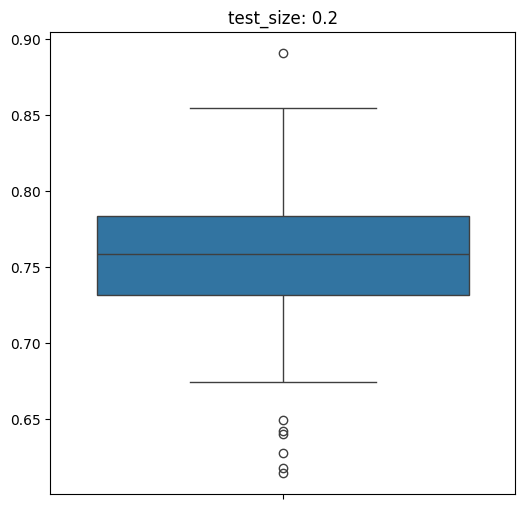

iqr: [0.73129328 0.7835995 ], ecart: -0.3014237857967095


In [88]:
X = scaler.fit_transform(df[Xs])
y = df['body_mass_g']
test_size = 0.2

score = []

for random_state in np.arange(200):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
    reg.fit(X_train, y_train)
    print(f"\\n Test_size: {test_size}, R^2: {reg.score(X_test, y_test):.3f}")
    score.append(reg.score(X_test, y_test))

fig = plt.figure(figsize=(6,6))
sns.boxplot(score)
plt.title(f"test_size: {test_size}")
plt.show()

iqr = np.quantile(score, q=[0.25, 0.75])
ecart = iqr[0] - iqr[1] / np.median(score)
print(f"iqr: {iqr}, ecart: {ecart}")

Choise of random_state during test and train split affects the score of the model

# 5. Classification with logistic regression

In [90]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

url = "https://raw.githubusercontent.com/OpenClassrooms-Student-Center/8063076-Initiez-vous-au-Machine-Learning/master/data/palmer_penguins.csv"

df = pd.read_csv(url)
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
...,...,...,...,...,...,...,...,...
339,Chinstrap,Dream,55.8,19.8,207.0,4000.0,male,2009
340,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female,2009
341,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male,2009
342,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male,2009


In [51]:
df['sex'].value_counts()

sex
male      168
female    165
Name: count, dtype: int64

In [91]:
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
df.dropna(inplace=True)
df['sex'] = df.sex.astype(int)

df['sex'].value_counts()

sex
0    168
1    165
Name: count, dtype: int64

In [92]:
y = df['sex'].values
X = scaler.fit_transform(df[Xs+['body_mass_g']])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = LogisticRegression(random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)
confusion_matrix(y_test, y_pred)

array([[28,  3],
       [ 6, 30]])

left column is negative so male

right column is positive so female

In [93]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(f"True Males: {tn}, False Females: {fp}, \nFalse Males: {fn}, True Females: {tp}")

True Males: 28, False Females: 3, 
False Males: 6, True Females: 30


# 6 Recall and precision

In [94]:
from sklearn.metrics import precision_score, recall_score


print(round(recall_score(y_test, y_pred), 3))
round(precision_score(y_test, y_pred), 3)

0.833


0.909

Recall = TP/ (TP + FN) so of actuall positives how many did we catch

Precision = TP/ (TP + FP) so of all predicted positives, how many were correct

Higher precision means less false positives

So less false females in our case

# 7. Probabilities

In [95]:
y_proba = clf.predict_proba(X_test)[:,1]
y_pred_03 = [0 if value < 0.3 else 1 for value in y_proba]
y_pred_07 = [0 if value < 0.7 else 1 for value in y_proba]

print(f"03 \n{confusion_matrix(y_test, y_pred_03)}")
print(f"07 \n{confusion_matrix(y_test, y_pred_07)}")

03 
[[22  9]
 [ 1 35]]
07 
[[30  1]
 [18 18]]


So the lower the threshold the more predicted females

The higher, hte more predicted males

# 8. Changing target and number of predictors

In [96]:
#change the target and convert one-hot code it
df['species']= df['species'].map({'Adelie':3, 'Chinstrap':2, 'Gentoo':1}).astype(int)
df['species'].value_counts()

species
3    146
1    119
2     68
Name: count, dtype: int64

In [97]:
y = df['species'].values

#1st model with body mass
X1 = scaler.fit_transform(df[Xs + ['body_mass_g']])
X1_train, X1_test, y_train, y_test = train_test_split(X1, y, test_size=0.2, random_state=42)

#2nd model without body mass
X2 = scaler.fit_transform(df[Xs])
X2_train, X2_test, y_train, y_test = train_test_split(X2, y, test_size=0.2, random_state=42)

#train both
clf1 = LogisticRegression(random_state=42)
clf1.fit(X1_train, y_train)
clf2 = LogisticRegression(random_state=42)
clf2.fit(X2_train, y_train)

y1_pred = clf1.predict(X1_test)
y2_pred = clf2.predict(X2_test)

#confusion matrix of both
print(f"Model with body mass \n{confusion_matrix(y_test, y1_pred)}")
print(f"Model without body mass \n{confusion_matrix(y_test, y2_pred)}")

Model with body mass 
[[18  0  0]
 [ 0 16  2]
 [ 0  0 31]]
Model without body mass 
[[18  0  0]
 [ 0 16  2]
 [ 0  0 31]]


Therefore we don't need to consider body mass

# 9. KMeans

In [98]:
X = scaler.fit_transform(df[Xs + ['body_mass_g'] + ['sex']])

from sklearn.cluster import KMeans
km = KMeans( n_clusters=3, random_state = 808, n_init = 10)
km.fit(X)
y_pred = km.labels_
df['labels'] = km.labels_

df[['species', 'labels', 'island']].groupby(by=['species', 'labels']).count().reset_index().rename(columns = {'island': 'count_'})

,species,labels,count_
0,1,0,58
1,1,2,61
2,2,0,34
3,2,1,34
4,3,0,73
5,3,1,73


# 10. Silhouette score

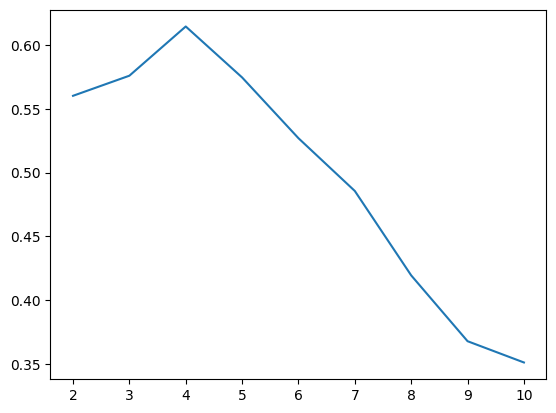

In [102]:
from sklearn.metrics import silhouette_score

scores = []
for n in range(2, 11, 1):
    km = KMeans( n_clusters=n, random_state = 808, n_init = 10)
    km.fit(X)
    labels_ = km.predict(X)
    scores.append(silhouette_score(X, labels_))

plt.plot(range(2, 11, 1), scores)